In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../dataset/train.csv")
df2 = pd.read_csv("../dataset/test.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


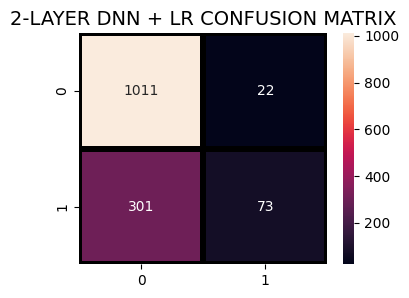

In [4]:
#layer 1: DNN
y_pred_proba_dnn = model.predict(X_test)
y_pred_dnn = (y_pred_proba_dnn > 0.5).astype("int32").flatten()
#filter churn candidates
churn_candidates = X_test[y_pred_dnn == 1]

# Layer 2: Logistic Regression filter churn again to pick up precision
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(churn_candidates)

final_predictions_lr = y_pred_dnn.copy()
final_predictions_lr[y_pred_dnn == 1] = y_pred_lr

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, final_predictions_lr), annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("2-LAYER DNN + LR CONFUSION MATRIX", fontsize=14)
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step


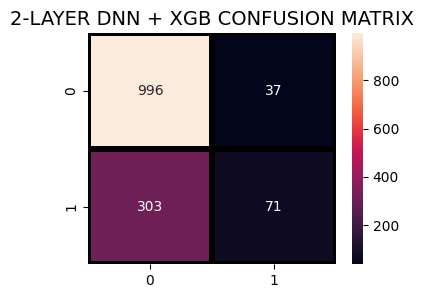

In [5]:
#DNN + XG boost
from xgboost import XGBClassifier

#layer 1: Still DNN
y_pred_proba_dnn = model.predict(X_test)
y_pred_dnn = (y_pred_proba_dnn > 0.5).astype("int32").flatten()
churn_candidates = X_test[y_pred_dnn == 1]

#layer 2: XGBoost
xgb_model = XGBClassifier(n_estimators=500, max_depth=10, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(churn_candidates)

final_predictions_xgb = y_pred_dnn.copy()
final_predictions_xgb[y_pred_dnn == 1] = y_pred_xgb

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, final_predictions_xgb), annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("2-LAYER DNN + XGB CONFUSION MATRIX", fontsize=14)
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step


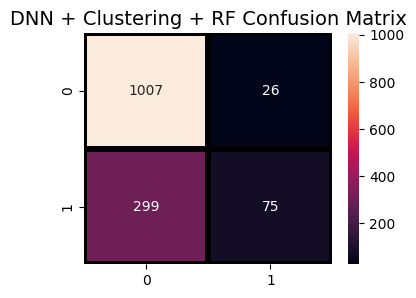

In [6]:
#DNN + clustering + RF
from sklearn.cluster import KMeans

#layer 1: DNN threshold
y_pred_proba_dnn = model.predict(X_test)
y_pred_dnn = (y_pred_proba_dnn > 0.62745).astype("int32").flatten()
# filter churn candidates
churn_candidates = X_test[y_pred_dnn == 1]

#layer 2: Clustering churn candidates
kmeans = KMeans(n_clusters=3, random_state=42)  # ví dụ chia thành 3 nhóm churn
clusters = kmeans.fit_predict(churn_candidates)
# add cluster ID vào churn_candidates
import pandas as pd
churn_candidates_clustered = pd.DataFrame(churn_candidates)
churn_candidates_clustered["cluster"] = clusters

#layer 3: RF to recheck
rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
#detect churn in each cluster
y_pred_rf = rf_model.predict(churn_candidates)

final_predictions = y_pred_dnn.copy()
final_predictions[y_pred_dnn == 1] = y_pred_rf

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, final_predictions), annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("DNN + Clustering + RF Confusion Matrix", fontsize=14)
plt.show()

In [7]:
#summary
data = {
    "Model": [
        "DNN (original)",
        "DNN (with class weight)",
        "DNN (new structure)",
        "DNN (new structure + threshold tuning)",
        "DNN + RF",
        "DNN + LR",
        "DNN + XGBoost",
        "DNN + Clustering + RF"
    ],
    "TN": [968, 798, 991, 1027, 993, 1011, 996, 1007],
    "FN": [65, 235, 42, 6, 40, 22, 37, 26],
    "FP": [199, 85, 227, 326, 234, 301, 303, 299],
    "TP": [175, 289, 147, 48, 140, 73, 71, 75]
}

df_results = pd.DataFrame(data)

styled_results = (
    df_results.style
    .background_gradient(cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse")
        ]}
    ])
)

styled_results

,Model,TN,FN,FP,TP
0,DNN (original),968,65,199,175
1,DNN (with class weight),798,235,85,289
2,DNN (new structure),991,42,227,147
3,DNN (new structure + threshold tuning),1027,6,326,48
4,DNN + RF,993,40,234,140
5,DNN + LR,1011,22,301,73
6,DNN + XGBoost,996,37,303,71
7,DNN + Clustering + RF,1007,26,299,75


In [9]:
data = {
    "Model": [
        "DNN (original)",
        "DNN (with class weight)",
        "DNN (new structure)",
        "DNN (new structure + threshold tuning)",
        "DNN + RF",
        "DNN + LR",
        "DNN + XGBoost",
        "DNN + Clustering + RF"
    ],
    "Accuracy": [0.81, 0.77, 0.81, 0.76, 0.81, 0.77, 0.76, 0.77],
    "Precision": [0.83, 0.90, 0.81, 0.76, 0.81, 0.77, 0.77, 0.77],
    "Recall": [0.94, 0.77, 0.96, 0.99, 0.96, 0.98, 0.96, 0.97],
    "F1-score": [0.88, 0.83, 0.88, 0.86, 0.88, 0.86, 0.86, 0.86]
}

df_results = pd.DataFrame(data)

styled_results = (
    df_results.style
    .background_gradient(cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse")
        ]}
    ])
)

styled_results

,Model,Accuracy,Precision,Recall,F1-score
0,DNN (original),0.810000,0.830000,0.940000,0.880000
1,DNN (with class weight),0.770000,0.900000,0.770000,0.830000
2,DNN (new structure),0.810000,0.810000,0.960000,0.880000
3,DNN (new structure + threshold tuning),0.760000,0.760000,0.990000,0.860000
4,DNN + RF,0.810000,0.810000,0.960000,0.880000
5,DNN + LR,0.770000,0.770000,0.980000,0.860000
6,DNN + XGBoost,0.760000,0.770000,0.960000,0.860000
7,DNN + Clustering + RF,0.770000,0.770000,0.970000,0.860000
